# РК1 Прокофьев Илья Викторович РТ5-61Б

## Вариант: 13
## Задание
Для заданного набора данных проведите обработку пропусков в данных для одного категориального и одного количественного признака. Какие способы обработки пропусков в данных для категориальных и количественных признаков Вы использовали? Какие признаки Вы будете использовать для дальнейшего построения моделей машинного обучения и почему? Для пары произвольных колонок данных построить график "Jointplot".

### Описание набора данных
Датасет содержит информацию о факторах, влияющих на поступление в магистратуру. Целевая переменная — вероятность поступления (Chance of Admit).

Признаки:
- Serial No. — порядковый номер (не используется для моделирования)
- GRE Score — балл GRE (от 260 до 340)
- TOEFL Score — балл TOEFL (от 0 до 120)
- University Rating — рейтинг университета (от 1 до 5)
- SOP — сила мотивационного письма (от 1 до 5)
- LOR — сила рекомендательных писем (от 1 до 5)
- CGPA — средний балл (от 0 до 10)
- Research — наличие исследовательского опыта (0 или 1)
- Chance of Admit — вероятность поступления (от 0 до 1)

#### Импорт библиотек

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Для воспроизводимости
np.random.seed(42)

#### Загрузка данных

In [3]:
df = pd.read_csv('D:\\6 семестр\\ML\\РК\\Данные\\archive\\Admission_Predict.csv')
print("Первые 5 строк:")
display(df.head())
print("\nИнформация о пропусках:")
print(df.isnull().sum())

Первые 5 строк:


,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65



Информация о пропусках:
Serial No.           0
GRE Score            0
TOEFL Score          0
University Rating    0
SOP                  0
LOR                  0
CGPA                 0
Research             0
Chance of Admit      0
dtype: int64


#### Cоздание категориального признака на основе University Rating

In [4]:
# Разбиваем рейтинг на три категории: Low (1-2), Medium (3), High (4-5)
df['Rating Category'] = pd.cut(df['University Rating'],
                               bins=[0, 2, 3, 5],
                               labels=['Low', 'Medium', 'High'])

# Проверим распределение
print(df['Rating Category'].value_counts())

Rating Category
High      134
Low       133
Medium    133
Name: count, dtype: int64


#### Искусственное внесение пропусков

In [5]:
# Для количественного признака (GRE Score) заменяем 5% случайных значений на NaN
n_missing = int(len(df) * 0.05)
missing_gre_idx = np.random.choice(df.index, size=n_missing, replace=False)
df.loc[missing_gre_idx, 'GRE Score'] = np.nan

# Для категориального признака (Rating Category) заменяем 5% случайных значений на NaN
missing_cat_idx = np.random.choice(df.index, size=n_missing, replace=False)
df.loc[missing_cat_idx, 'Rating Category'] = np.nan

print("Пропуски после внесения:")
print(df[['GRE Score', 'Rating Category']].isnull().sum())

Пропуски после внесения:
GRE Score          20
Rating Category    20
dtype: int64


#### Обработка пропусков

In [6]:
# Количественный признак: заполнение медианой
gre_median = df['GRE Score'].median()
df['GRE Score'] = df['GRE Score'].fillna(gre_median)
print(f"GRE Score заполнен медианой: {gre_median}")

# Категориальный признак: заполнение модой (наиболее частой категорией)
cat_mode = df['Rating Category'].mode()[0]
df['Rating Category'] = df['Rating Category'].fillna(cat_mode)
print(f"Rating Category заполнен модой: {cat_mode}")

# Проверка, что пропусков больше нет
print("\nПропуски после обработки:")
print(df[['GRE Score', 'Rating Category']].isnull().sum())

GRE Score заполнен медианой: 317.0
Rating Category заполнен модой: Medium

Пропуски после обработки:
GRE Score          0
Rating Category    0
dtype: int64


Способы обработки пропусков:
- Для количественного признака (GRE Score) использована медиана, так как она устойчива к выбросам и не искажает распределение.
- Для категориального признака (Rating Category) использована мода (наиболее частое значение), что является стандартным подходом для номинальных признаков.

Признаки для дальнейшего построения моделей:
- Все числовые признаки (GRE Score, TOEFL Score, University Rating, SOP, LOR, CGPA, Research), кроме Serial No. (идентификатор).
- Категориальный признак Rating Category можно использовать после кодирования (например, one-hot encoding), но он дублирует информацию University Rating. Поэтому в модель лучше включить либо University Rating (как порядковый), либо Rating Category (как номинальный), либо оба, если есть основания считать, что нелинейное преобразование улучшит качество. В данном случае оставим исходные числовые признаки, так как они уже содержат всю информацию.
- Целевая переменная: Chance of Admit.

#### jointplot для двух произвольных колонок

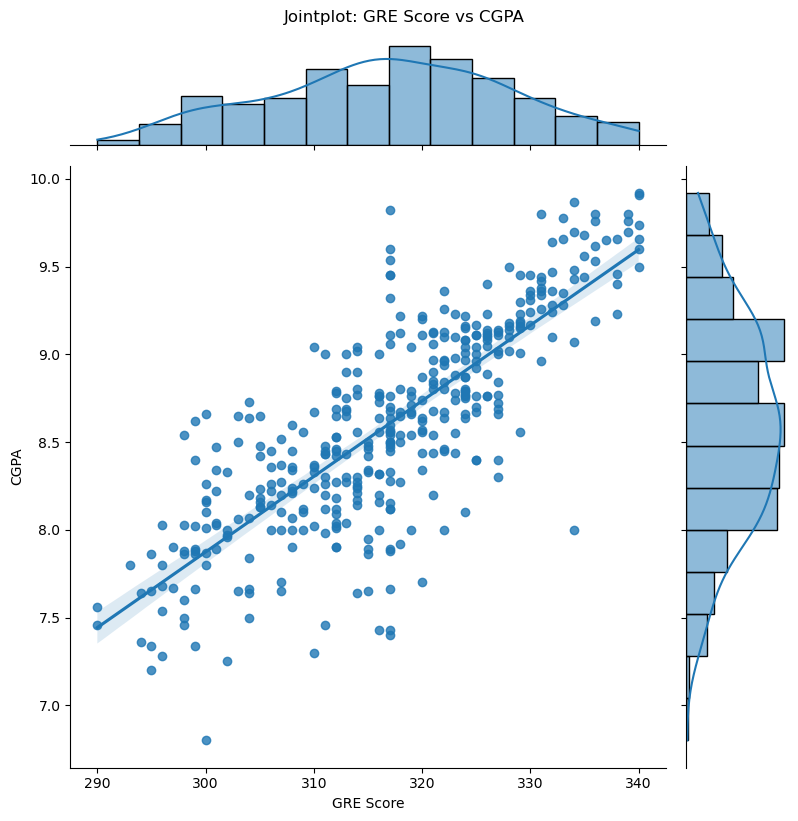

In [7]:
# Построим совместное распределение GRE Score и CGPA
sns.jointplot(data=df, x='GRE Score', y='CGPA', kind='reg', height=8)
plt.suptitle('Jointplot: GRE Score vs CGPA', y=1.02)
plt.show()